# Table of Contents
---

### 1. [**Goal of this Lab**](#section:goal)

### 2. [**Preliminaries**](#section:preliminaries)


### 3. [**Part 1: Translating Spanish to Aragonese**](#section:translation)
* #### [**Dataset Preparation**](#section:es_an_dataset)
* #### [**Finetune a Pretrained Transformer**](#section:train_mt5)
* #### [**Evaluate a Finetuned Model**](#section:eval_mt5)
* #### [**Attention Visualization**](#section:attention_visualization)

### 4. [**Part 2: Translating Idiomatic Sentences**](#section:idiomatic)

### 5. [**Part 3: The effect of tokenization**](#section:tokenization)

### 6. [**Conclusion**](#section:conclusion)

### 7. [**Acknowledgements**](#section:acknowledgements)



<a name="section:goal"></a>
# Goal of this Lab

**<ins>What we are going to do in the lab</ins>**

Our goal in this lab is to further explore transformers in terms of inputs/outputs, attention weights, and the impact of tokenization.


In the previous lab, you had the chance to deep dive into the elementary blocks of a transformer on a toy task. Here we will focus on a real-world task of translating sentences from one language (Spanish) to another very-low resource language (Aragonese). The objective of this lab is for you to get a deep understanding of how the transformer works with hands-on experience. You will interact with [Aya](https://arxiv.org/abs/2402.07827) a state-of-the-art multilingual model and inspect predictions when translating sentences containing an idiom or a metaphorical multi-word expression.
Finally, we conclude this lab by examining the impact of small variations of the input text on how the model perceives it in terms of tokens.


More specifically the lab is split into 5 parts:


* Part 1: We finetune a pretrained model transformer to translate sentences from Spanish to Aragonese.
* Part 2: We explore more state-of-the-art models on translating idiomatic sentences.
* Part 3: Highlights the effect of tokenization and how words with very similar meanings but slight variations due to different dialects, historical conventions etc are presented to the model.
* Conclusion: We summarze some of the most significant changes in the architecture of the transformer as well as potential alternative architectures that compete with transformers.

<a name="section:preliminaries"></a>
# Prelimaries

Lets install dependencies here

In [ ]:
!pip install -U datasets evaluate sacrebleu tokenizers altair bertviz

Import libraries that we want to use throughout the lab

In [2]:
import json
import math
import os
from collections.abc import Iterable
from pathlib import Path
from typing import Literal

import altair as alt
import datasets
import evaluate
import pandas as pd
import tokenizers
import torch
import transformers
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    PreTrainedModel,
    PreTrainedTokenizerFast,
)

<a name="section:translation"></a>
# Part 1: Translating Spanish to Aragonese

<a name="section:es_an_dataset"></a>
## Dataset Preparation

From the [WMT 24 website](https://www2.statmt.org/wmt24/romance-task.html): In Spain, a diverse linguistic landscape exists, including, beyond the widely recognized Spanish, other languages such as Basque, Catalan, and Galician. Although Spanish is obviously at the forefront in terms of the volume of resources available for training data-driven MT systems, the capabilities and richness of the other languages should not be underestimated. This task focuses on three of them, namely, Aragonese, Aranese, and Asturian.



In the sections below we will train a model from scratch that tries to translate sentences from Spanish to Aragonese.




Download the train and validation datasets

In [ ]:
!wget https://huggingface.co/gpantaz/athnlp_lab4_data/resolve/main/train_an-es.json?download=true -O train_an-es.json
!wget https://huggingface.co/gpantaz/athnlp_lab4_data/resolve/main/val_an-es.json?download=true -O val_an-es.json

### Prepare the test dataset

In [ ]:
!rm -rf FLORES*
!wget https://github.com/transducens/PILAR/raw/main/FLORES+.zip
!apt-get install p7zip-full

In [ ]:
# Click on the running output cell below to open a password window
# Use `multilingual machine translation` as password
!ls
!7z x "FLORES+.zip"

In [6]:
spanish_devtest = "devtest/devtest.spa_Latn"
aragonese_devtest = "devtest/devtest.arg_Latn"
output_json_file = "flores+_devtest.json"

with open(spanish_devtest) as fp:
    spanish_sentences = [line.rstrip() for line in fp]

with open(aragonese_devtest) as fp:
    aragonese_sentences = [line.rstrip() for line in fp]

all_sentences = [
    {"es": spanish_sentence, "an": aragonese_sentence}
    for spanish_sentence, aragonese_sentence in zip(
        spanish_sentences, aragonese_sentences, strict=False
    )
]
with open(output_json_file, "w") as fp:
    json.dump(all_sentences, fp, indent=4)

del spanish_sentences
del aragonese_sentences

Lets create a Hugging Face dataset that we can use for our experiments

In [ ]:
hf_dataset = datasets.load_dataset(
    "json",
    data_files={
        "train": "train_an-es.json",
        "val": "val_an-es.json",
        "test": "flores+_devtest.json",
    },
)

Lets see a couple of examples:

In [ ]:
print(hf_dataset["train"][0])
print(hf_dataset["train"][20])
print(hf_dataset["train"][-1])

Note that our dataset is quite noisy! Even if you dont understand Spanish or Aragonese you can definitely see that some pairs of sentences do not have the same meaning. That is something quite common in uncurated and/or low-resource data that we occasionally have to deal with!

Finally, a utility function to load a pretrained model from Hugging Face library along with the tokenizer, this will be used later on where we load a pretrained model and try to finetune it on the spanish-aragonese translation task.

In [11]:
def load_pretrained_model(
    model_name: str = "google-t5/t5-base",
) -> tuple[PreTrainedModel, PreTrainedTokenizerFast]:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model = model.eval()
    return model, tokenizer

<a name="section:train_mt5"></a>
## Finetune a Pretrained Transformer

You probably have noticed that the predictions of our model are very unsatisfactory. Why?


Notice that our training data is pretty noisy. Even if you do not speak Spanish or Aragonese you can surely understand that some pairs are not exactly "aligned", i.e the meaning of the two sentences is not the same.


Additionally, most state-of-the-art models across many NLP tasks are trained with a vast amount of resources, are significantly larger than our toy model, and are trained for many hours on a GPU cluster with hundreds of nodes (not on a colab for 20 mins!).


These two issues are the primary bottlenecks in many applications:
* How to obtain clean, high quality data for my machine translation task?
* How can I use a capable model with limited compute?




Here, we will only provide a partial solution to the second problem. We will use a pretrained model, i.e a model that was trained with lots of data for many hours on a different task as a starting point. We say that we finetune a pretrained model by training it on our smaller data task and for fewer training updates. In other words, instead of randomly initializing the weights of our model, we will use the weights of the pretrained model and continue to train on our translation task.


More specifically, we will use the  [mT5](https://aclanthology.org/2021.naacl-main.41/) model which is essentially an encoder-decoder transformer trained on a multilingual dataset of 101 languages. mT5 is based on the [Text-to-Text Transfer Transformer (T5)](https://www.jmlr.org/papers/v21/20-074.html) that uses a unified text-to-text format and scale achieve state-of-the-art results on a wide variety of English-only NLP tasks.

In [9]:
def preprocess_text(text: str) -> str:
    """Minimal text preprocessing."""
    text = text.strip()
    text = text[0].upper() + text[1:]
    if not text.endswith("."):
        text += "."
    return text


def preprocess_function(
    examples: datasets.formatting.formatting.LazyBatch,
    tokenizer: transformers.models.t5.tokenization_t5_fast.T5TokenizerFast,
) -> dict[str, torch.Tensor]:
    """Preprocess the examples."""
    inputs = [example.strip() for example in examples["es"]]
    targets = [example.strip() for example in examples["an"]]
    model_inputs = tokenizer(inputs, text_target=targets, max_length=64, truncation=True)
    # Return the inputs to the model, ie the input_ids, attention_mask and labels
    return model_inputs

In [ ]:
pretrained_checkpoint_name = "google/mt5-base"

model, tokenizer = load_pretrained_model(pretrained_checkpoint_name)

tokenized_dataset = hf_dataset.map(
    preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=pretrained_checkpoint_name)

In [ ]:
max_train_examples = 5000
if max_train_examples is not None:
    tokenized_dataset["train"] = tokenized_dataset["train"].select(list(range(max_train_examples)))

max_val_examples = 2500
if max_val_examples is not None:
    tokenized_dataset["val"] = tokenized_dataset["val"].select(list(range(max_val_examples)))

print(tokenized_dataset)

**Warning**: Due to limited resources on google colab it is very likely that you will not be able to train a model. The code below is for educational purposes, you can skip it and directly go to the evaluation section. We will provide you with a trained model using exactly the same code and training hyperparameters for you so that you can inspect predictions.

In [ ]:
# Dont use wandb to log the experiment
os.environ["WANDB_DISABLED"] = "true"

training_args = transformers.TrainingArguments(
    output_dir="storage/models/mt5-base-model-es-an-translation",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    logging_steps=1,
    save_strategy="steps",
    save_steps=0.2,
    num_train_epochs=2,
    learning_rate=1e-5,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    bf16=True,
    fp16=False,
    gradient_checkpointing=False,
    save_total_limit=2,
    load_best_model_at_end=True,
    log_level="debug",
    save_safetensors=True,
    eval_strategy="steps",
    eval_steps=0.2,
    seed=12345,
    data_seed=12345,
    dataloader_num_workers=2,
    logging_nan_inf_filter=False,
)

model.config.keys_to_ignore_at_inference.append("logits")

trainer = transformers.Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

<a name="section:eval_mt5"></a>
## Evaluate a Finetuned Model

Load the already finetuned model from [Hugging Face](https://huggingface.co/gpantaz/athnlp_lab4_mt5_base) and measure BLEU and CHRF++ scores.

Note that we will use the [.generate()](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/text_generation#transformers.GenerationMixin.generate) to do autoregressive generation. This is a built-in functionality of models from Hugging Face for greedy decoding, and other generation methods.


In [ ]:
# Load the finetuned model
model, tokenizer = load_pretrained_model("gpantaz/athnlp_lab4_mt5_base")

tokenized_dataset = hf_dataset.map(
    preprocess_function, batched=True, fn_kwargs={"tokenizer": tokenizer}
)

predictions = []
references = []
# Set this to len(test_dataset) to evaluate on the whole test set
# It takes too long though!
max_examples = 100
for example in tqdm(tokenized_dataset["test"], total=max_examples, desc="Running inference"):
    input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(model.device)
    attention_mask = torch.tensor(example["attention_mask"]).unsqueeze(0).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=128,
            output_attentions=True,
            return_dict_in_generate=True,
        )
        outputs_str = tokenizer.batch_decode(outputs["sequences"], skip_special_tokens=True)
        predictions.extend(outputs_str)

        references.extend([example["es"]])

    if len(predictions) == max_examples:
        break

bleu = evaluate.load("sacrebleu")
bleu_results = bleu.compute(predictions=predictions, references=references)

chrf_plusplus = evaluate.load("chrf", word_order=2)
chrf_plusplus_results = chrf_plusplus.compute(predictions=predictions, references=references)

print(f"BLEU: {bleu_results}")
print(f"CHRF++: {chrf_plusplus_results}")

del bleu
del chrf_plusplus
del predictions
del references

<a name="section:attention_visualization"></a>
## Attention Visualization

In the final section of Part 4, we can view the attention weights from each layer of the encoder or the decoder.

Run the below cell and inspect the attention weights for the encoder. Use the dropdown menu on the left to change the view to the self attention, or the cross attention of the decoder. Which tokens attend to each other the most?

Some of the visualizations will fail (runtime disconnection) when the input text is long. We have truncated the input to a maximum of 40 characters but you can try and remove this and/or introduce the `include_layers` parameter to output only a selection of layers.

In [ ]:
from bertviz import model_view

pair = hf_dataset["test"][39]

print(pair["es"])
print(pair["an"])

# Truncate the input to a maximum of 40 tokens to ensure that the plot doesnt fail
encoder_input_ids = tokenizer(pair["es"], return_tensors="pt", add_special_tokens=True).input_ids[:, :40]
decoder_input_ids = tokenizer(pair["an"], return_tensors="pt", add_special_tokens=True).input_ids[:, :40]

encoder_input_ids = encoder_input_ids.to(device=model.device)
decoder_input_ids = decoder_input_ids.to(device=model.device)

with torch.no_grad():
    outputs = model(input_ids=encoder_input_ids, decoder_input_ids=decoder_input_ids, output_attentions=True)

encoder_text = tokenizer.convert_ids_to_tokens(encoder_input_ids[0])
decoder_text = tokenizer.convert_ids_to_tokens(decoder_input_ids[0])

model_view(
    encoder_attention=outputs.encoder_attentions,
    decoder_attention=outputs.decoder_attentions,
    cross_attention=outputs.cross_attentions,
    encoder_tokens= encoder_text,
    decoder_tokens=decoder_text,
    #include_layers=[0, 4, 8, 11],
)

<a name="section:idiomatic"></a>
# Part 2: Translating Idiomatic Sentences


An idiom is a phrase or expression that usually presents a figurative, non-literal meaning attached to the phrase (see [details](https://en.wikipedia.org/wiki/Idiom)).




For example the Greek sentence:


''Ο Γιάννης μου ανάβει το λαμπάκια κάθε φορά που μιλάει για Αναδρομικά Νευρωνικά Δίκτυα''


Can translate literally into:


''Yannis turns my lights on when he mentions Recurrent Neural Networks''


However, that is not exactly the meaning of this sentence for the non-Greek speakers among us, this means that he makes me angry, not horny!


---
**Do translation models address figurative language?**


In this section we are going to qualitatively and collaboratively assess how well state-of-the-art multilingual models handle sentences with figurative meaning. For this purpose we are going to use [Aya](https://arxiv.org/pdf/2402.07827) a multilingual model hosted on Hugging Face 🤗


Below are some additional examples of figurative language and their literal translation. If you understand Greek you can run the below cell and copy the printed output to the Aya model. Alternatively, try to come up with examples of figurative sentences in Greek and modify the `sentences` list. If you do not understand Greek, replace the `source_language` with your own and fill in the `sentences` list with some examples of your own.


| Example              | Meaning | Literal Translation |
| :---------------- | :------ | ---- |
| Ο Γιάννης μου ανάβει το λαμπάκια κάθε φορά που μιλάει για Αναδρομικά Νευρωνικά Δίκτυα | Yannis makes me angry when he mentions Recurrent Neural Networks | Yannis turns my lights on when he mentions Recurrent Neural Networks |
| Είδα τη Μαρία προχτές, την έχει πάρει η κατηφόρα | I saw Maria the other day, she has gone downhill | I saw Maria the other day, she has gone downhill |
| Χτες πήγα σε ενα μπαρ στο κέντρο της Αθήνας και έφαγα πόρτα | Yesterday I went on bar at the center of Athens but I was denied from entering | Yesterday I went on bar at the center of Athens but I ate a door |
| Ρώτησα την Αθηνά για το συμβαν και έκανε την πάπια | I asked Athina about what happened but she pretended to know nothing about it | I asked Athina about what happened but she was behaving like a duck |
| Πήγα για κούρεμα και πλήρωσα κυριολεκτικά τα μαλλιά της κεφαλής μου | I got a new haircut but it was really expensive | I got a new haircut but I paid the hair of my head |
| Ο δεύτερος κριτής μου ζητάει πολλες αλλαγές στη δημοσιευση, σκάει γάιδαρο | Reviewer #2 requested a lot of changes to my manuscript, they are very persistent | Reviewer #2 requested a lot of changes to my manuscript, they burst a donkey |


Run the below cell then go to the Hugging Face Space (https://huggingface.co/spaces/CohereForAI/aya-23-35b). Copy-paste the printed output from the cell below into the chat interface to interact with the model.




Try to come up with creative examples. Our goal here is to try to understand the limitations of these models.If you find something interesting you can also share it with us on the Slack channel!

In [ ]:
# Pick your own source / target language
source_language = "Greek"
target_language = "English"

prompt = (
    "Translate the following sentence from {source_language} to {target_language}:\n{sentence}"
)

# Replace the following sentences with your own in the same language as the source language
sentences = [
    "Ο Γιάννης μου ανάβει το λαμπάκια κάθε φορά που μιλάει για Αναδρομικά Νευρωνικά Δίκτυα",
    "Είδα τη Μαρία προχτές, την έχει πάρει η κατηφόρα",
    "Πήγα σε ενα μπαρ στο κέντρο της Αθήνας και έφαγα πόρτα",
    "Ρώτησα την Αθηνά για το συμβαν και έκανε την πάπια",
    "Πήγα για κούρεμα και πλήρωσα κυριολεκτικά τα μαλλιά της κεφαλής μου",
    "Ο δεύτερος κριτής μου ζητάει πολλες αλλαγές στη δημοσιευση, σκάει γάιδαρο",
]

for sentence in sentences:
    # Copy paste the printed text into Aya and see how it responds
    print(
        prompt.format(
            source_language=source_language.capitalize(),
            target_language=target_language.capitalize(),
            sentence=sentence,
        )
    )
    print("---")

<a name="section:tokenization"></a>
# Part 3: The effect of tokenization

#### Why is tokenization a weakness of LLMs?
Tokenization is necessary in order to be able to plug text into modern language models but can be the root of many problems. With tokenization we are able to create indices for the embedding table to obtain vectors that feed into the Transformer model. So these vectors are how the model perceives a token. **Which charactesrs, words, or sub-words, should be combined together?** 🤔

Let's assume that a token is a single character, then we will have a small embedding table that represents all possible words, however, even a small sentence will be represented as a very long sequence for the model, making it hard to predict the next token while also having very long sequences 😢

Let's assume that a token is a word (possibly splitting by a whitespace or punctuation), then we may have a larger embedding table but our sequences will be shorter. However, at test time it is highly likely that a word is not present in our vocabulary. Even if we choose an <unk> token to represent this words we would have the same vector corresponding to multiple words that possibly have a completely different meaning 😢

**Can we have something in between?** 😀

<div align="center">

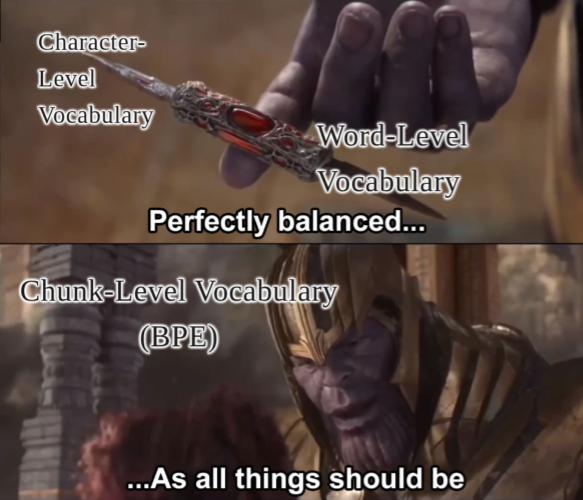


Modern state-of-the-art models operate on a chunk-level where a word is split into separate chunks and each chunk corresponds to a token. The GPT-2 paper, [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) applied the [Byte Pair Encoding (BPE) algorithm](https://en.wikipedia.org/wiki/Byte_pair_encoding) as a way to create vocabularies for language models, essentially solving the problem of out-of-vocabulary tokens. BPE is now applied to many language models including [LLaMA](https://arxiv.org/abs/2302.13971), [Mistral](https://arxiv.org/abs/2310.06825), and so on.


Despite the success of BPE, tokenization is still a crucial component in the development that oftentimes is the root for many problems of these models and these problems tend to be further shown particularly when our data is noisy or sparse. Some examples include:


* Performance on tasks with non-english languages is worse than tasks focusing exclusively on English
* Spelling tasks
* Coding tasks
* Performance variation when using different structured input (JSON / YAML)
* If you had asked ChatGPT earlier about [SolidGoldMagikarp](https://www.lesswrong.com/posts/aPeJE8bSo6rAFoLqg/solidgoldmagikarp-plus-prompt-generation) you would see the model go totally crazy on a uncompletely unrelated topic


Finally, note that even with BPE, tokenization is a learning algorithm meaning that we introduce a training step that essentially determines how the model perceives a sentence by chunking the sentence into multiple parts. As a result, training a model is never end-to-end!

As you have already seen, most of the models opt for a specific approach in designing their tokenizer and thus expect very strict formats in their inputs. We will also explore this even further by examining the effect of in-context demonstrations, system prompts, and chain-of-thought in the next lab.

For now, lets go to a [web-app](https://huggingface.co/spaces/gpantaz/athnlp2025_tokenization) and play a couple of tokenizers and type some input text which will be tokenized using two different tokenizers into two separate sequences.



Let's try a simple example as shown below which involves adding two numbers:
```
127+677=804
127 + 677 = 804
```


<div align="center">

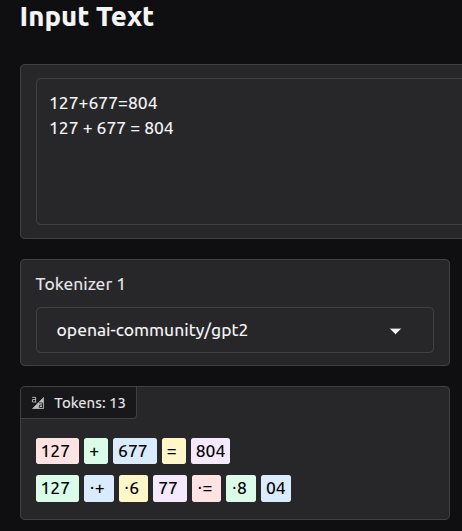

Notice that the two examples are nearly identical, where the only difference is that we have added the white space between the '+', and '=' signs.
These slight variations are often not a problem for humans, and in fact in many cases they improve clarity.

However, if the model in fact had to compute the addition of the two numbers it needs to take into account these small changes, and in many of these cases can very easily break it.

Let's try a couple of Greek examples as well using [KriKri](https://huggingface.co/ilsp/Llama-Krikri-8B-Base), a model that is trained in greek inputs

<div align="center">

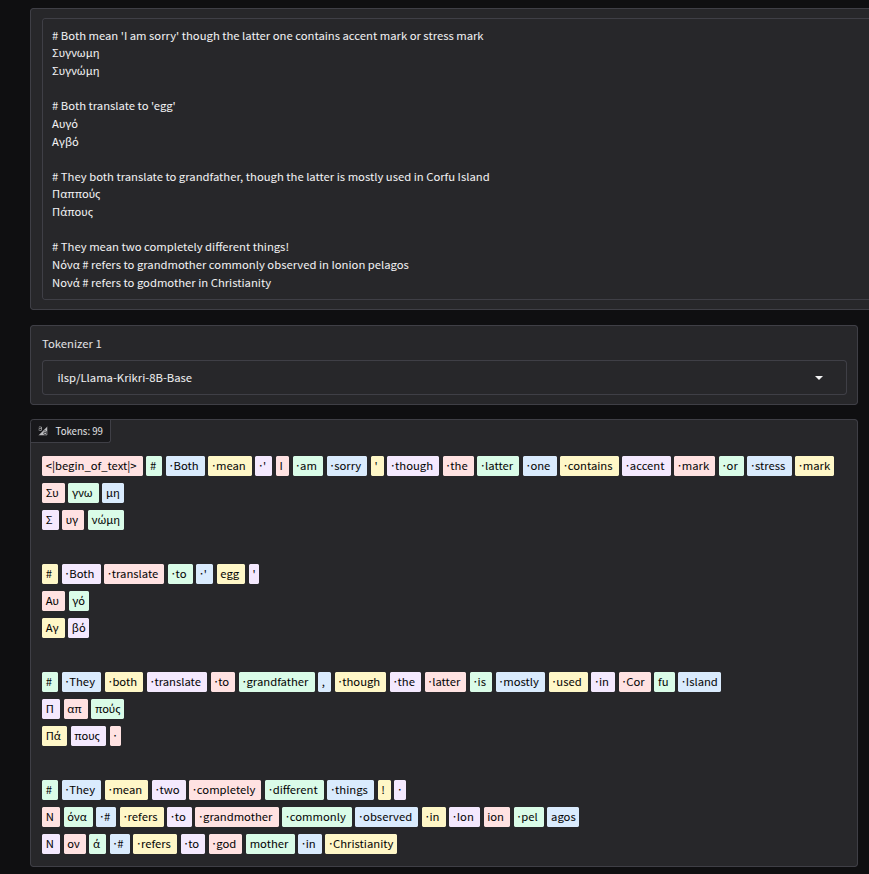

These variations often arise from:

* Regional dialect differences
* Historical spelling conventions
* Phonetic changes over time
* Influence from ancient vs. modern Greek orthography
* Simplification in everyday writing


If you play with more modern models you will perhaps see that many of these issues are "solved". This is an outcome of a tedious effort in designing the vocabulary of the model before training so that most of these variations do not have a significant impact on how the model perceives the input text.


Feel free to try some of your own! Have a look at the examples in the dropdown, play with different tokenizers, languages and domains

<a name="section:conclusion"></a>
# Conclusion

## Some things that we did not cover

---
## What has changed from the original Transformer architecture?


### Pre-layernorm vs Post-layernorm
If you have been paying attention we did not follow the exact implementation of the vanilla transformer. The original approach follows what we now refer to as "post-layernorm", where the layernorm is applied after encoding. By contrast, in "pre-layernorm" we apply layer normalization before encoding. This was actually a mistake by the authors that was fixed after the release of the paper (see details [here](https://github.com/tensorflow/tensor2tensor/commit/f5c9b17e617ea9179b7d84d36b1e8162cb369f25))


In 2020 the paper [On Layer Normalization in the Transformer Architecture](https://proceedings.mlr.press/v119/xiong20b) further confirmed the superiority of the pre-layer norm over the post-layer norm approach.


### Positional Embeddings
The vanilla Transformer adds sinusoidal positional information at the token level. However, as we already explained, sinusoidal embeddings significantly modify both the magnitude and the angle of a token embedding based on the position in the sequence. Additionally, sinusoidal embeddings make the extrapolating inference to longer sequences challenging. For these reasons, most modern models [Gemma](https://arxiv.org/abs/2403.08295), [LLaMA](https://arxiv.org/abs/2302.13971), or [Mistral](https://arxiv.org/abs/2310.06825) have pivoted from this design choice by incorporating the positional information at the attention mechanism.


The paper [Train Short, Test Long: Attention with Linear Biases Enables Input Length Extrapolation](https://openreview.net/forum?id=R8sQPpGCv0) was one of the first papers to model positional information at the attention level by introducing the ALiBI embeddings, where the positional bias between the query-key attention scores proportional to their distance.


[Roformer: Enhanced transformer with rotary position embedding](https://www.sciencedirect.com/science/article/abs/pii/S0925231223011864) introduces RoPE embeddings which are now being applied to most Transformer models that basically rotates the query and key vectors based on their position in the sequence.


### Encoder-Decoder vs Decoder-only models
Recall that in the previous lab where we explained the attention mechanism, we trained a decoder-only model.

The models that we used in this lab, and in fact, the vanilla Transformer in fact is an encoder-decoder, where the encoder computes the embeddings of the input sequence (lets' say the text in source language for the task of machine translation), and the decoder predicts the next token (let's say the text in the target langauge) via cross-attention of the embeddings of encoder and conditioned on all previous predictions.


While in principle encoder-decoder models perform on par with decoder-only models, the latter are increasingly becoming the de facto option for modern language models.
When training models at scale with thousands of documents and trillions of words, computational efficiency is key. Decoder-only offers a solution to this problem because they allow practitioners to divide the model on multiple GPUs in an easier way compared to encoder-decoder models which are composed of multiple Transformers.

---
## Alternative architectures that compete with transformers


While Transformers have been established as the core block for most applications, there are some works that try to adopt architectures without the attention mechanism. The latter, while powerful, introduces substantial complexity particularly in tasks that require processing very long sequences. To address this many works try to scale up recurrent models that rival Transformers both in raw performance as well as computational overhead. We provide a few references for those who are interested:


* [Hungry Hungry Hippos: Towards Language Modeling with State Space Models](https://openreview.net/forum?id=COZDy0WYGg)
* [RWKV: Reinventing RNNs for the Transformer Era](https://openreview.net/forum?id=7SaXczaBpG)
* [Mamba: Linear-Time Sequence Modeling with Selective State Spaces](https://arxiv.org/pdf/2312.00752)
* [Transformers are SSMs: Generalized Models and Efficient Algorithms Through Structured State Space Duality](https://arxiv.org/abs/2405.21060)

<a name="section:acknowledgement"></a>
# Acknowledgements

This notebook is based on existing learning material for Transformers including:

* [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)
* Andrej Karpathy's tutorial on Transformers: [Let's build the GPT Tokenizer](https://youtu.be/zduSFxRajkE)
* Andrej Karpathy's tutorial on Tokenization: [Let's build GPT: from scratch, in code, spelled out](https://youtu.be/kCc8FmEb1nY)